# Tokenizer Fertility and RankMe: Does Tokenization Efficiency Shape Representation Geometry?

**Author:** Giacomo Porpiglia

---

## Research Question

> **Does tokenizer *fertility* — the average number of subword tokens generated per word — correlate with the RankMe score of the resulting representations? And how does this relationship evolve across layers and training checkpoints?**

Tokenizer **fertility** for language $\ell$ is defined as:

$$\text{fertility}(\ell) = \frac{\sum_{t \in \mathcal{T}_\ell} |\text{tokenize}(t)|}{\sum_{t \in \mathcal{T}_\ell} |\text{words}(t)|}$$

For script-continuous languages (Chinese, Japanese) where word boundaries are absent, $|\text{words}(t)|$ is replaced by $|\text{chars}(t)|$ (non-whitespace characters), so the unit becomes *tokens per character*.

A high-fertility language is one the tokenizer encodes **inefficiently** — it fragments text into many small subword pieces rather than whole morphemes. We investigate whether this fragmentation leaves a measurable signature in the *geometry* of learned representations, as captured by **RankMe** (the effective dimensionality of the activation matrix, measured via Shannon entropy of singular values).

### Hypotheses

| # | Hypothesis | Why it might hold |
|---|------------|-------------------|
| H1 | **Layer-wise signature**: fertility predicts RankMe at the final checkpoint, especially in late layers. | Semantic information is concentrated in later layers; poor tokenization may reduce representational diversity there. |
| H2 | **Depth profile**: the fertility–RankMe correlation changes across depth. | Early layers capture token-level patterns (directly tied to tokenization); later layers capture abstractions. |
| H3 | **Training trajectory**: high- and low-fertility languages follow different RankMe growth curves. | The model may learn efficient representations for low-fertility languages faster/more completely. |


In [1]:
# ── CONFIGURATION — only this cell needs to change to switch models ────────────
import yaml

CONFIG_YAML = "../geometry_analysis/configs/fuxi_wiki_all.yaml"
# CONFIG_YAML = "../geometry_analysis/configs/fuxi_wiki.yaml"   # ← switch here for Fuxi
# ──────────────────────────────────────────────────────────────────────────────

with open(CONFIG_YAML) as f:
    _cfg = yaml.safe_load(f)

TOKENIZER_NAME = _cfg["model"]["name"]
RESULTS_CSV    = "../" + _cfg["output"]["results_path"]
MODEL_LABEL    = TOKENIZER_NAME.split("/")[-1]   # e.g. 'Apertus-8B-2509' or 'FuxiTranyu-8B'

DATASET_CONFIGS = {ds["name"]: ds for ds in _cfg["datasets"]}

print(f"Model      : {TOKENIZER_NAME}")
print(f"Results CSV: {RESULTS_CSV}")
print(f"Model label: {MODEL_LABEL}")
print(f"Datasets   : {list(DATASET_CONFIGS.keys())}")

import pathlib as _pl
YAML_STEM  = _pl.Path(CONFIG_YAML).stem          # e.g. 'apertus_wiki'
STATIC_DIR = f'statics_giacomo/{YAML_STEM}'
_pl.Path(STATIC_DIR).mkdir(parents=True, exist_ok=True)
print(f'Statics dir: {STATIC_DIR}')

Model      : TJUNLP/FuxiTranyu-8B
Results CSV: ../results/fuxi_wiki_all.csv
Model label: FuxiTranyu-8B
Datasets   : ['English', 'Chinese', 'French', 'Indonesian', 'Italian', 'Swahili', 'Spanish', 'German', 'Hindi', 'Arabic', 'Turkish', 'Vietnamese', 'Japanese']
Statics dir: statics_giacomo/fuxi_wiki_all


In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 0. Load Results

The results CSV path is read from the config file above (`output.results_path`).  
If the file does not exist, run the geometry analysis pipeline first:
```
python geometry_analysis/geometry_analysis.py --config <CONFIG_YAML>
```

In [3]:
if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError(
        f"Results file not found: {RESULTS_CSV}\n"
        f"Generate it by running:\n"
        f"  python geometry_analysis/geometry_analysis.py --config {CONFIG_YAML}"
    )

df = pd.read_csv(RESULTS_CSV)
data_label = MODEL_LABEL

print(f"Loaded {len(df):,} rows | model: {MODEL_LABEL}")
print(f"Checkpoints : {df.checkpoint.nunique()}")
print(f"Languages   : {sorted(df.dataset.unique())}")
print(f"Layers      : {df.layer.nunique()}")
print(f"Aggregations: {df.aggregation.unique().tolist()}")
df.head(3)

Loaded 45,240 rows | model: FuxiTranyu-8B
Checkpoints : 58
Languages   : ['Arabic', 'Chinese', 'English', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Layers      : 30
Aggregations: ['last', 'mean']


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,10B,English,layer_0,last,166.1150,25.7605,1.292614,0.1808,0.2926,0.3522,0.4673,0.5820,0.7165,0.8752,0.9527,0.9865
1,10B,English,layer_1,last,219.4165,28.3090,1.073115,0.1747,0.2717,0.3238,0.4278,0.5334,0.6613,0.8249,0.9184,0.9708
2,10B,English,layer_2,last,237.0938,30.2344,0.991134,0.1671,0.2706,0.3287,0.4310,0.5319,0.6533,0.8092,0.9021,0.9603


In [4]:
def ckpt_key(name):
    """Numeric sort key for checkpoint names: tokens seen, 'main' goes last."""
    if str(name).lower() == "main":
        return float("inf")
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2).upper() == "T" else val
    return float("inf") - 1

def layer_num(name):
    m = re.search(r"(\d+)", str(name))
    return int(m.group(1)) if m else 0

def ckpt_label(name):
    """Compact checkpoint label: '210B', '15T', 'main'."""
    if str(name).lower() == "main":
        return "main"
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    return f"{m.group(1)}{m.group(2)}" if m else name

checkpoints = sorted(df.checkpoint.unique(), key=ckpt_key)
languages   = sorted(df.dataset.unique())
layers      = sorted(df.layer.unique(), key=layer_num)
layer_nums  = [layer_num(l) for l in layers]
ckpt_labels = [ckpt_label(c) for c in checkpoints]

# Use last-token aggregation throughout (causal LM prediction target)
df_last = df[df.aggregation == "last"].copy()

print(f"Checkpoints : {checkpoints[0]} … {checkpoints[-1]}  ({len(checkpoints)} total)")
print(f"Layers      : layer_{layer_nums[0]} … layer_{layer_nums[-1]}  ({len(layers)} total)")

Checkpoints : 10B … main  (58 total)
Layers      : layer_0 … layer_29  (30 total)


## 1. Tokenizer Fertility

We load the model's tokenizer (as specified in the config) and sample Wikipedia articles for each language to measure how many subword tokens are generated per word (or per character for Chinese and Japanese).

**Fallback values** (approximate, calibrated for Llama-style BPE tokenizers such as Apertus) are pre-loaded below. Set `COMPUTE = True` in the next cell and run it on the cluster to replace them with exact values for the configured model.

> **Note:** The approximate fallback values may be inaccurate for models with very different tokenizer designs (e.g. FuxiTranyu, which is optimised for Chinese). Always prefer computed values.

> **Why Wikipedia?** Wikipedia provides encyclopedic, formally written text across all 13 languages. Using the same domain for both fertility computation and RankMe analysis ensures the measurements are directly comparable.

In [5]:
# Approximate fertility values — calibrated for Llama-style BPE tokenizers (e.g. Apertus).
# May not be accurate for other architectures (e.g. FuxiTranyu). Run the next cell to compute exact values.
# Unit: tokens/word for word-boundary languages; tokens/char for Chinese and Japanese.
APPROX_FERTILITY = {
    "English":    (1.32, "tok/word"),
    "Spanish":    (1.46, "tok/word"),
    "Italian":    (1.47, "tok/word"),
    "French":     (1.55, "tok/word"),
    "Indonesian": (1.67, "tok/word"),
    "Swahili":    (1.84, "tok/word"),
    "German":     (1.87, "tok/word"),
    "Turkish":    (2.18, "tok/word"),
    "Vietnamese": (2.32, "tok/word"),
    "Arabic":     (2.96, "tok/word"),
    "Hindi":      (4.73, "tok/word"),
    "Chinese":    (1.52, "tok/char"),
    "Japanese":   (1.87, "tok/char"),
}

fertility = {lang: v for lang, (v, _) in APPROX_FERTILITY.items()}
fert_unit = {lang: u for lang, (_, u) in APPROX_FERTILITY.items()}
print("Fallback fertility values loaded.")
print("Set COMPUTE=True in the next cell to replace with exact values for:", MODEL_LABEL)
vocab_coverage_pct   = {}   # filled by COMPUTE block; empty until then
vocab_coverage_count = {}

Fallback fertility values loaded.
Set COMPUTE=True in the next cell to replace with exact values for: FuxiTranyu-8B


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  CLUSTER CELL — set COMPUTE = True to replace approximate values above.
#  Requires: transformers, datasets, internet access, HuggingFace token if needed.
#  TOKENIZER_NAME is read automatically from the config cell.
# ─────────────────────────────────────────────────────────────────────────────
N_ARTICLES = 1000    # Wikipedia articles sampled per language

COMPUTE = True

if COMPUTE:
    from transformers import AutoTokenizer
    from datasets import load_dataset
    import json, pathlib

    CJK = {'Chinese', 'Japanese'}

    # Dataset info (path, subset, split) comes directly from the YAML — no hardcoding needed.
    # Only compute for languages present in the results.
    subsets_to_run = {name: ds for name, ds in DATASET_CONFIGS.items() if name in languages}

    print(f'Loading tokenizer: {TOKENIZER_NAME}')
    tok = AutoTokenizer.from_pretrained(TOKENIZER_NAME, trust_remote_code=True)
    print(f'Vocab size: {tok.vocab_size:,}\n')

    computed_fertility, computed_unit = {}, {}
    computed_coverage_pct, computed_coverage_count = {}, {}

    for lang, ds_cfg in subsets_to_run.items():
        print(f'  {lang}...', end=' ', flush=True)
        ds = load_dataset(ds_cfg['path'], ds_cfg['subset'],
                          split=ds_cfg.get('split', 'train'), streaming=True)
        texts = [item['text'] for _, item in zip(range(N_ARTICLES), ds)]

        tok_total, unit_total = 0, 0
        all_ids = set()
        for text in texts:
            text = text.strip()
            if not text:
                continue
            ids = tok.encode(text, add_special_tokens=False)
            tok_total += len(ids)
            all_ids.update(ids)
            if lang in CJK:
                unit_total += len(''.join(text.split()))   # non-whitespace chars
            else:
                unit_total += len(text.split())             # whitespace-split words

        unit = 'tok/char' if lang in CJK else 'tok/word'
        f    = tok_total / unit_total if unit_total else float('nan')
        cov  = round(100 * len(all_ids) / tok.vocab_size, 2)

        computed_fertility[lang]       = round(f, 4)
        computed_unit[lang]            = unit
        computed_coverage_count[lang]  = len(all_ids)
        computed_coverage_pct[lang]    = cov
        print(f'{f:.3f} {unit}  |  coverage {cov:.1f}%')

    # Persist for reproducibility
    out_path = pathlib.Path(f'../results/fertility_{MODEL_LABEL}.json')
    out_path.write_text(json.dumps({
        'model':                TOKENIZER_NAME,
        'fertility':            computed_fertility,
        'unit':                 computed_unit,
        'vocab_coverage_pct':   computed_coverage_pct,
        'vocab_coverage_count': computed_coverage_count,
    }, indent=2))
    print(f'\nSaved to {out_path}')

    fertility            = computed_fertility
    fert_unit            = computed_unit
    vocab_coverage_pct   = computed_coverage_pct
    vocab_coverage_count = computed_coverage_count
    print('Fertility and vocabulary coverage values updated from tokenizer computation.')
else:
    print('COMPUTE=False — using approximate fallback values.')

Loading tokenizer: TJUNLP/FuxiTranyu-8B
Vocab size: 250,680

  English... 

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (11149 > 1024). Running this sequence through the model will result in indexing errors


1.651 tok/word  |  coverage 15.9%
  Chinese... 0.784 tok/char  |  coverage 11.4%
  French... 

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

1.681 tok/word  |  coverage 16.1%
  Indonesian... 1.690 tok/word  |  coverage 13.7%
  Italian... 1.695 tok/word  |  coverage 14.6%
  Swahili... 2.297 tok/word  |  coverage 7.9%
  Spanish... 1.565 tok/word  |  coverage 15.6%
  German... 

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

1.916 tok/word  |  coverage 16.4%
  Hindi... 3.669 tok/word  |  coverage 4.8%
  Arabic... 1.826 tok/word  |  coverage 9.5%
  Turkish... 1.996 tok/word  |  coverage 12.5%
  Vietnamese... 1.245 tok/word  |  coverage 12.6%
  Japanese... 0.652 tok/char  |  coverage 10.9%

Saved to ../results/fertility_FuxiTranyu-8B.json
Fertility and vocabulary coverage values updated from tokenizer computation.


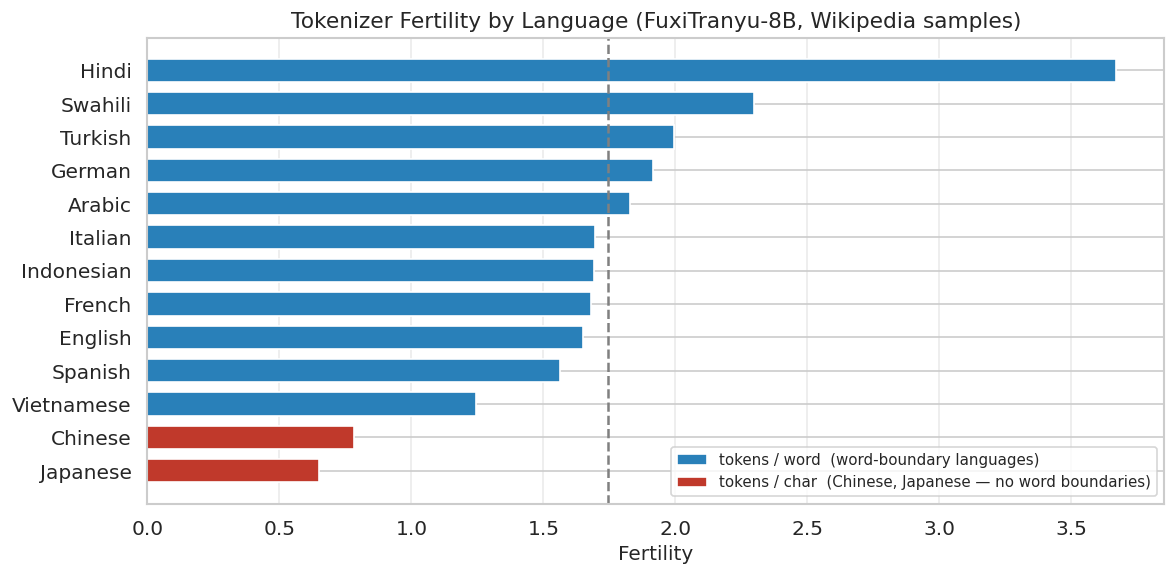

  language  fertility     unit
  Japanese     0.6516 tok/char
   Chinese     0.7840 tok/char
Vietnamese     1.2445 tok/word
   Spanish     1.5647 tok/word
   English     1.6512 tok/word
    French     1.6813 tok/word
Indonesian     1.6904 tok/word
   Italian     1.6951 tok/word
    Arabic     1.8263 tok/word
    German     1.9157 tok/word
   Turkish     1.9963 tok/word
   Swahili     2.2973 tok/word
     Hindi     3.6694 tok/word


In [7]:
df_fert = (
    pd.DataFrame({
        "language":  list(fertility.keys()),
        "fertility": list(fertility.values()),
        "unit":      [fert_unit[l] for l in fertility],
    })
    .sort_values("fertility")
    .reset_index(drop=True)
)

# Only keep languages present in the RankMe results
common_langs = [l for l in df_fert.language if l in languages]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#c0392b" if fert_unit[lang] == "tok/char" else "#2980b9"
              for lang in df_fert.language]
ax.barh(df_fert.language, df_fert.fertility, color=bar_colors, height=0.7, edgecolor="white")
ax.axvline(df_fert.fertility.mean(), ls="--", color="gray", lw=1.5,
           label=f"Mean = {df_fert.fertility.mean():.2f}")
ax.set_xlabel("Fertility", fontsize=12)
ax.set_title(f"Tokenizer Fertility by Language ({MODEL_LABEL}, Wikipedia samples)", fontsize=13)
legend_elems = [
    Patch(facecolor="#2980b9", label="tokens / word  (word-boundary languages)"),
    Patch(facecolor="#c0392b", label="tokens / char  (Chinese, Japanese — no word boundaries)"),
]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/fertility_bar_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print(df_fert.to_string(index=False))

### 1b. Vocabulary Coverage

For each language we count how many **distinct token IDs** appear across the N sampled Wikipedia articles — i.e. what fraction of the full vocabulary the language actually activates.

- A **high-coverage** language touches many corners of the token space, suggesting broad lexical variety or a rich character combination space.
- A **low-coverage** language reuses a small, concentrated token subset — possibly because the tokenizer is well-matched to it (e.g. English) or because its writing system uses a small character set.

Coverage and fertility are complementary measurements:
- **Fertility** measures *density*: tokens per word — how fragmented encoding is for each text fragment.
- **Coverage** measures *breadth*: which tokens are used — how diverse the token distribution is across the corpus sample.

> **Note:** Coverage values require `COMPUTE=True` in the cluster cell above. The chart below will be empty if that block has not been run.

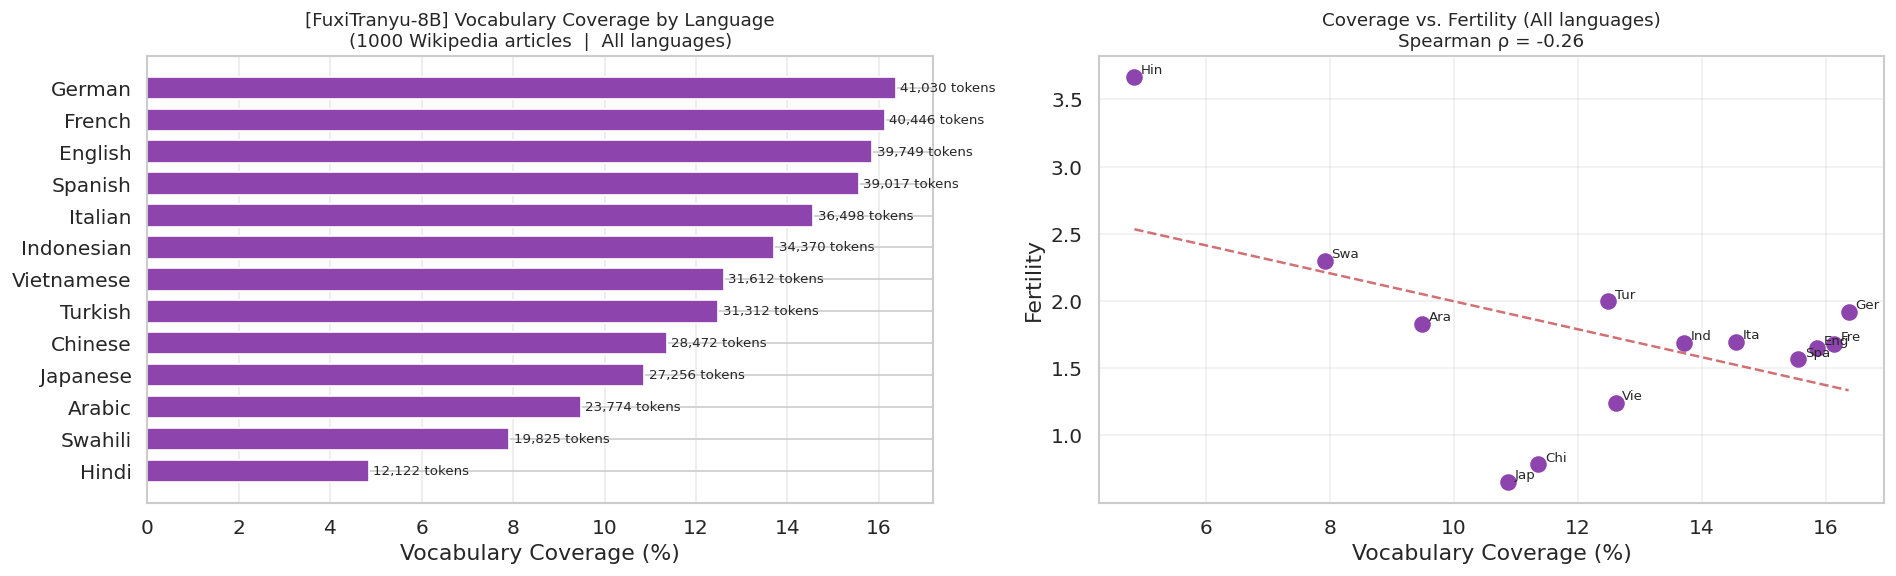

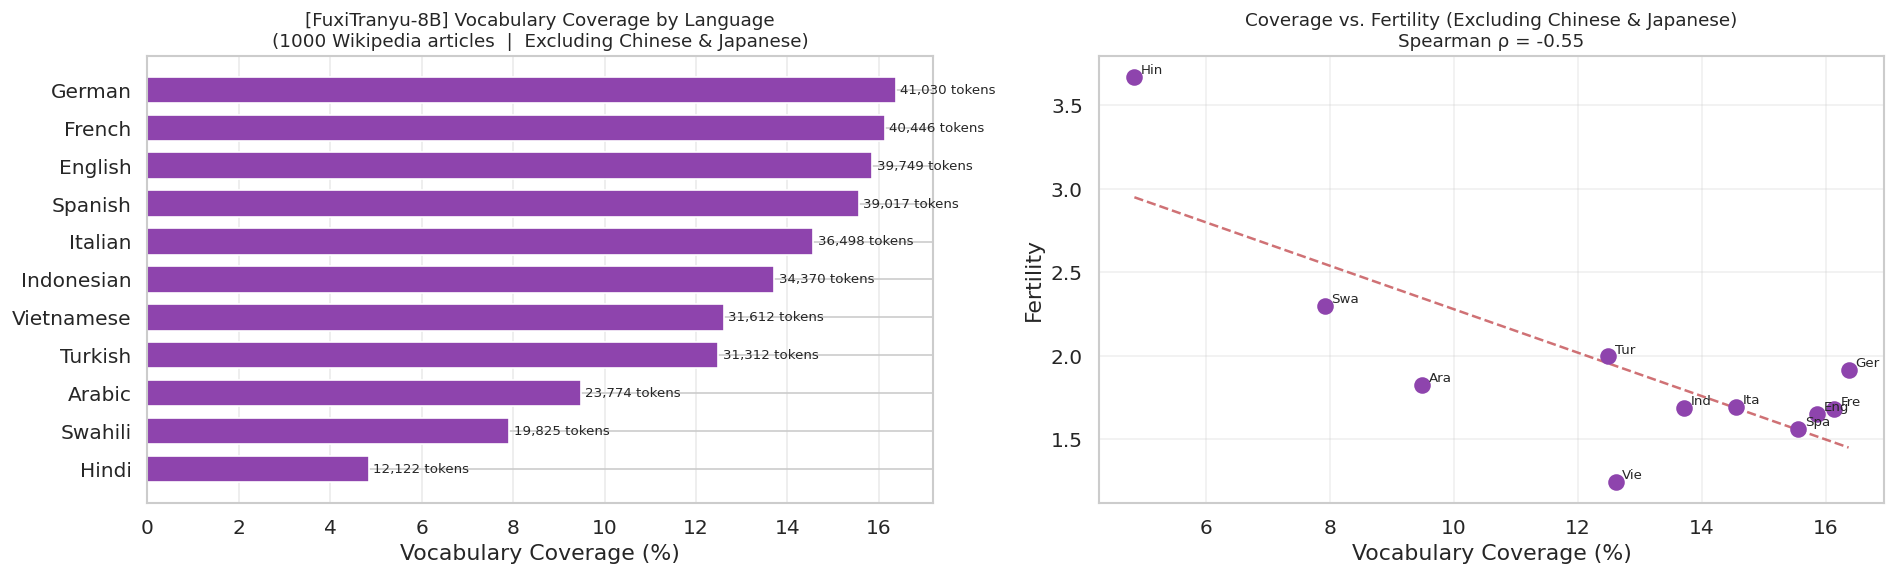

  language  coverage_pct  coverage_count
     Hindi          4.84           12122
   Swahili          7.91           19825
    Arabic          9.48           23774
  Japanese         10.87           27256
   Chinese         11.36           28472
   Turkish         12.49           31312
Vietnamese         12.61           31612
Indonesian         13.71           34370
   Italian         14.56           36498
   Spanish         15.56           39017
   English         15.86           39749
    French         16.13           40446
    German         16.37           41030


In [8]:
if not vocab_coverage_pct:
    print('No vocabulary coverage data available — run the COMPUTE block with COMPUTE=True.')
else:
    cov_df = (
        pd.DataFrame({
            'language':       list(vocab_coverage_pct.keys()),
            'coverage_pct':   list(vocab_coverage_pct.values()),
            'coverage_count': [vocab_coverage_count[l] for l in vocab_coverage_pct],
        })
        .sort_values('coverage_pct')
        .reset_index(drop=True)
    )

    CJK_LANGS = {'Chinese', 'Japanese'}

    for subset_label, excl, suffix in [
        ('All languages',                set(),      '_all'),
        ('Excluding Chinese & Japanese', CJK_LANGS,  '_no_cjk'),
    ]:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # ── Left: coverage bar chart ──────────────────────────────────────────
        ax = axes[0]
        cov_sub = cov_df[~cov_df.language.isin(excl)].reset_index(drop=True)
        ax.barh(cov_sub.language, cov_sub.coverage_pct,
                color='#8e44ad', height=0.7, edgecolor='white')
        ax.set_xlabel('Vocabulary Coverage (%)')
        ax.set_title(
            f'[{MODEL_LABEL}] Vocabulary Coverage by Language\n'
            f'({N_ARTICLES} Wikipedia articles  |  {subset_label})',
            fontsize=11,
        )
        ax.grid(axis='x', alpha=0.4)
        for i, row in cov_sub.iterrows():
            ax.text(row.coverage_pct + 0.1, i,
                    f'{int(row.coverage_count):,} tokens', va='center', fontsize=8)

        # ── Right: coverage vs. fertility scatter ─────────────────────────────
        ax = axes[1]
        common_cov = [l for l in vocab_coverage_pct if l in fertility and l not in excl]
        xs_cov  = np.array([vocab_coverage_pct[l] for l in common_cov])
        ys_fert = np.array([fertility[l]           for l in common_cov])

        ax.scatter(xs_cov, ys_fert, s=80, color='#8e44ad', zorder=3)
        for x, y, lab in zip(xs_cov, ys_fert, common_cov):
            ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords='offset points', fontsize=8)
        if len(xs_cov) >= 3:
            z    = np.polyfit(xs_cov, ys_fert, 1)
            xfit = np.linspace(xs_cov.min(), xs_cov.max(), 80)
            ax.plot(xfit, np.polyval(z, xfit), 'r--', lw=1.5, alpha=0.8)
            rho_cf, _ = spearmanr(xs_cov, ys_fert)
            ax.set_title(
                f'Coverage vs. Fertility ({subset_label})\nSpearman \u03c1 = {rho_cf:.2f}',
                fontsize=11,
            )
        ax.set_xlabel('Vocabulary Coverage (%)')
        ax.set_ylabel('Fertility')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{STATIC_DIR}/vocab_coverage_{MODEL_LABEL}{suffix}.png', dpi=150, bbox_inches='tight')
        plt.show()

    print(cov_df.to_string(index=False))


## 2. RankMe at the Final Checkpoint

We examine the RankMe layer profile for each language at the final training checkpoint (`main`), using the **last-token** aggregation.

Lines are colored by fertility (low = bright, high = dark), so visual clusters immediately reveal whether fertility tracks RankMe level.

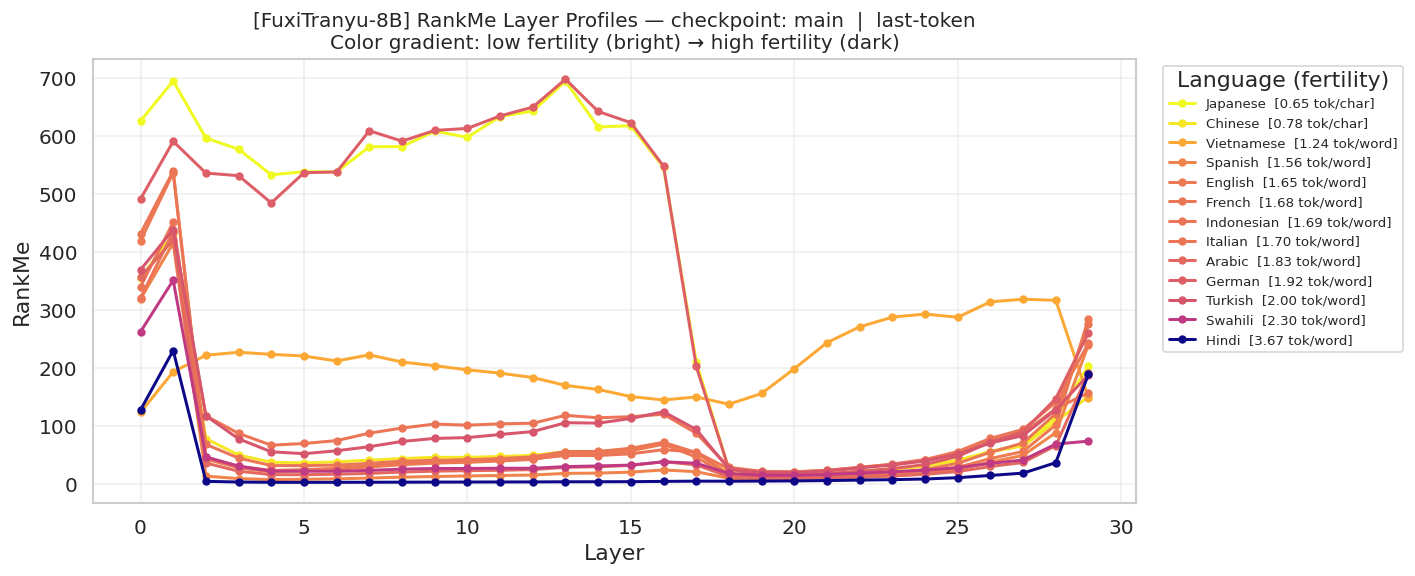

In [9]:
FINAL_CKPT = "main" if "main" in checkpoints else checkpoints[-1]
df_final = df_last[df_last.checkpoint == FINAL_CKPT]

fert_vals = [fertility[l] for l in common_langs if l in [lv for lv in fertility]]
fmin, fmax = min(fert_vals), max(fert_vals)
cmap = plt.cm.plasma_r   # low fertility = bright/yellow, high = dark/purple

fig, ax = plt.subplots(figsize=(12, 5))
for lang in sorted(common_langs, key=lambda l: fertility[l]):
    sub = (df_final[df_final.dataset == lang]
           .sort_values("layer", key=lambda s: s.map(layer_num)))
    if sub.empty:
        continue
    f = fertility[lang]
    color = cmap((f - fmin) / (fmax - fmin + 1e-9))
    ax.plot(
        sub.layer.map(layer_num), sub.rankme,
        marker="o", ms=4, lw=1.8, color=color,
        label=f"{lang}  [{f:.2f} {fert_unit.get(lang, '')}]",
    )

ax.set_xlabel("Layer")
ax.set_ylabel("RankMe")
ax.set_title(
    f"[{MODEL_LABEL}] RankMe Layer Profiles — checkpoint: {FINAL_CKPT}  |  last-token\n"
    "Color gradient: low fertility (bright) → high fertility (dark)",
    fontsize=12,
)
ax.legend(title="Language (fertility)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/layer_profiles_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Fertility–RankMe Correlation

For each layer at the final checkpoint, we compute Pearson $r$ and Spearman $\rho$ between fertility and RankMe across the languages present in the results.

> **Caveat:** With only ~13 data points the correlation estimates carry wide confidence intervals. The analysis should be read as exploratory — we look for consistent directional trends across layers rather than individually significant p-values.

### 3a. Scatter Plots at Selected Layers

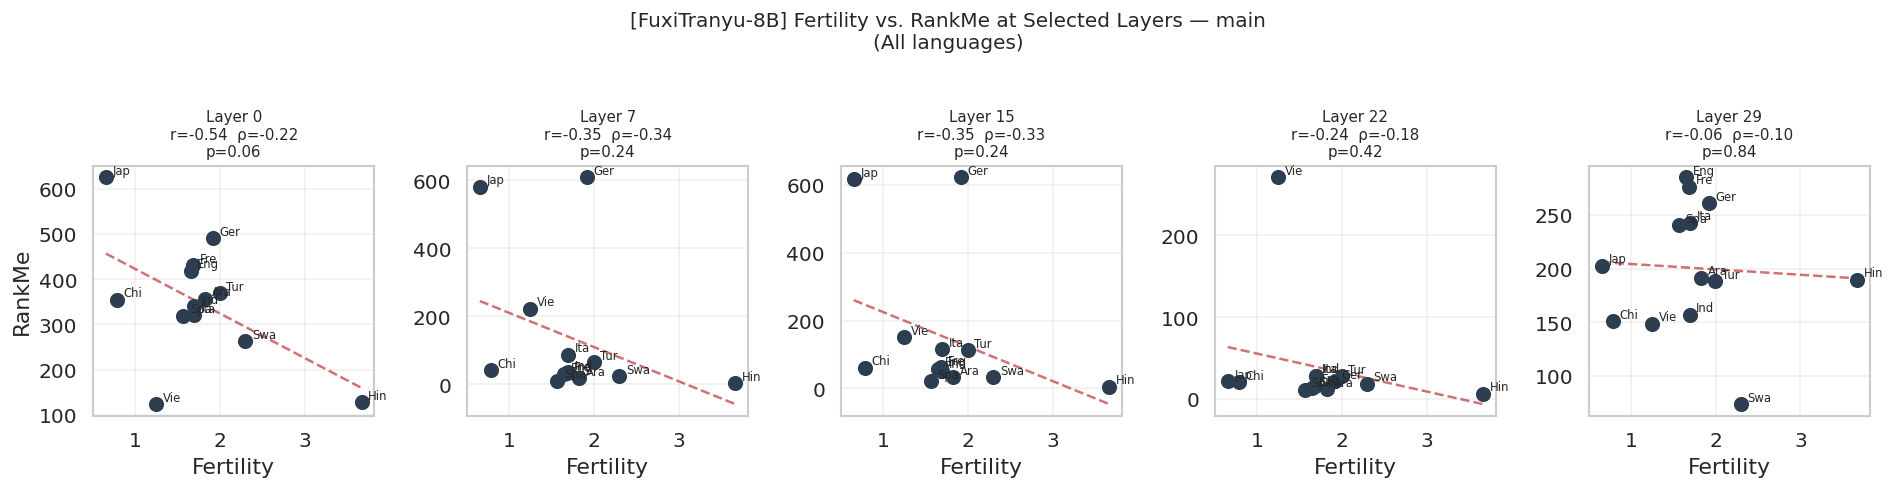

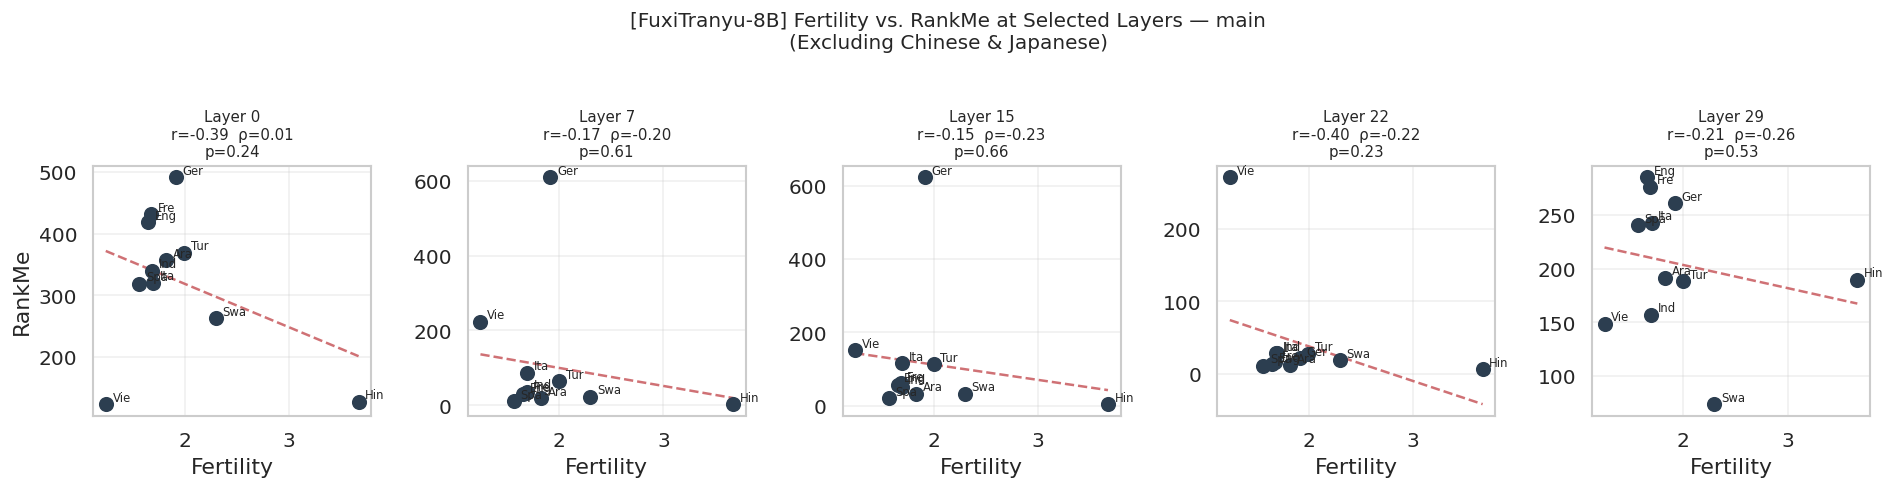

In [10]:
CJK_LANGS = {"Chinese", "Japanese"}
n = len(layers)
sel_layers = [layers[0], layers[n // 4], layers[n // 2], layers[3 * n // 4], layers[-1]]

for subset_label, excl, suffix in [
    ("All languages",                set(),      "_all"),
    ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
]:
    langs_sub = [l for l in common_langs if l not in excl]
    fig, axes = plt.subplots(1, len(sel_layers), figsize=(16, 4), sharey=False)
    for ax, layer in zip(axes, sel_layers):
        sub = df_final[df_final.layer == layer]
        xs, ys, labels = [], [], []
        for lang in langs_sub:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs.append(fertility[lang])
                ys.append(row.rankme.values[0])
                labels.append(lang)

        xs, ys = np.array(xs), np.array(ys)
        if len(xs) < 3:
            ax.set_title(f"L{layer_num(layer)}\n(no data)")
            continue

        r,   p   = pearsonr(xs, ys)
        rho, _   = spearmanr(xs, ys)

        ax.scatter(xs, ys, s=65, color="#2c3e50", zorder=3)
        for x, y, lab in zip(xs, ys, labels):
            ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=7)

        z    = np.polyfit(xs, ys, 1)
        xfit = np.linspace(xs.min(), xs.max(), 80)
        ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)

        ax.set_title(f"Layer {layer_num(layer)}\nr={r:.2f}  \u03c1={rho:.2f}\np={p:.2f}", fontsize=9)
        ax.set_xlabel("Fertility")
        if layer == sel_layers[0]:
            ax.set_ylabel("RankMe")
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"[{MODEL_LABEL}] Fertility vs. RankMe at Selected Layers \u2014 {FINAL_CKPT}\n({subset_label})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/scatter_fertility_rankme_{MODEL_LABEL}{suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()


### 3b. Correlation Profile Across All Layers

The profile shows how tightly fertility and RankMe track each other as a function of depth.  
Gold bands mark layers where Pearson $r$ is statistically significant at $p < 0.05$.

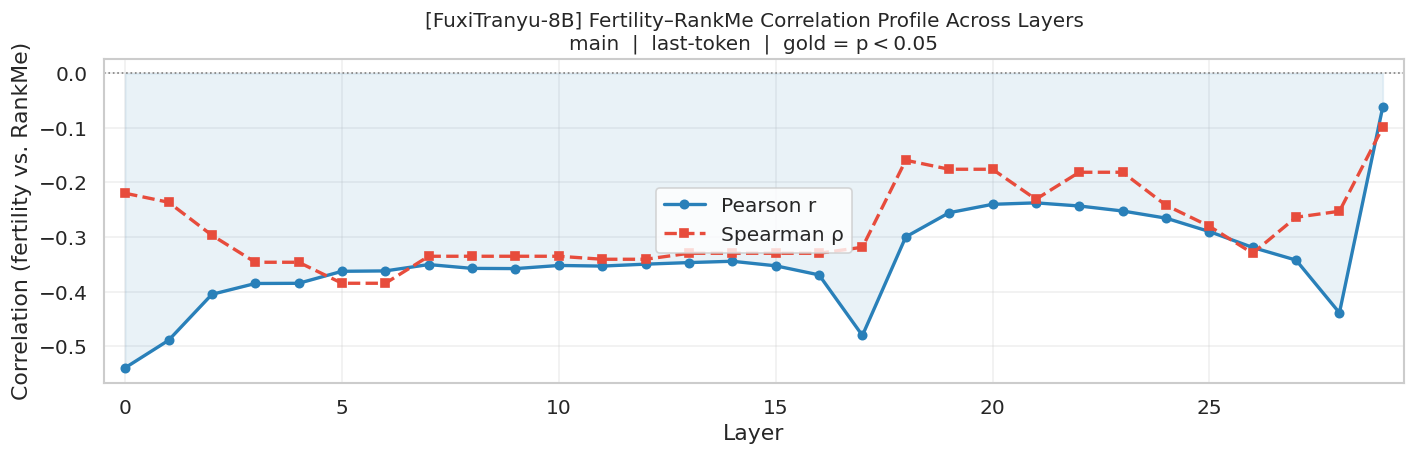

Layers with |r| > 0.5:
 layer  pearson_r  spearman_rho  p_value
     0  -0.539391      -0.21978 0.057121


In [11]:
prs, rhos, pvals = [], [], []
for layer in layers:
    sub = df_final[df_final.layer == layer]
    xs, ys = [], []
    for lang in common_langs:
        row = sub[sub.dataset == lang]
        if not row.empty:
            xs.append(fertility[lang])
            ys.append(row.rankme.values[0])
    if len(xs) < 3:
        prs.append(np.nan); rhos.append(np.nan); pvals.append(np.nan)
        continue
    r, p   = pearsonr(xs, ys)
    rho, _ = spearmanr(xs, ys)
    prs.append(r); rhos.append(rho); pvals.append(p)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layer_nums, prs,  "o-",  color="#2980b9", lw=2, ms=5, label="Pearson r")
ax.plot(layer_nums, rhos, "s--", color="#e74c3c", lw=2, ms=5, label="Spearman \u03c1")
ax.axhline(0, color="gray", lw=1, ls=":")
ax.fill_between(layer_nums, prs, 0, alpha=0.1, color="#2980b9")

sig_added = False
for lnum, p in zip(layer_nums, pvals):
    if p is not None and not np.isnan(p) and p < 0.05:
        label = "p < 0.05" if not sig_added else None
        ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.18, color="gold", zorder=0, label=label)
        sig_added = True

ax.set_xlabel("Layer")
ax.set_ylabel("Correlation (fertility vs. RankMe)")
ax.set_title(
    f"[{MODEL_LABEL}] Fertility\u2013RankMe Correlation Profile Across Layers\n"
    f"{FINAL_CKPT}  |  last-token  |  gold = p\u202f<\u202f0.05",
    fontsize=12,
)
ax.legend()
ax.set_xlim(-0.5, layer_nums[-1] + 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/correlation_profile_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

df_corr = pd.DataFrame({"layer": layer_nums, "pearson_r": prs, "spearman_rho": rhos, "p_value": pvals})
print("Layers with |r| > 0.5:")
print(df_corr[df_corr.pearson_r.abs() > 0.5].to_string(index=False))

### 3c. Coverage–RankMe Correlation Profile

We repeat the layer-by-layer Spearman rank correlation analysis, substituting **vocabulary coverage** for fertility. Overlaying both curves reveals whether coverage adds independent predictive power:

- If the curves **track each other**, fertility and coverage carry the same signal — one redundant with the other.
- If they **diverge** at certain layers, coverage captures a distinct geometric signature (e.g. breadth of token usage may matter more in middle layers than density).

> **Note:** This section requires vocabulary coverage data from the COMPUTE block above.

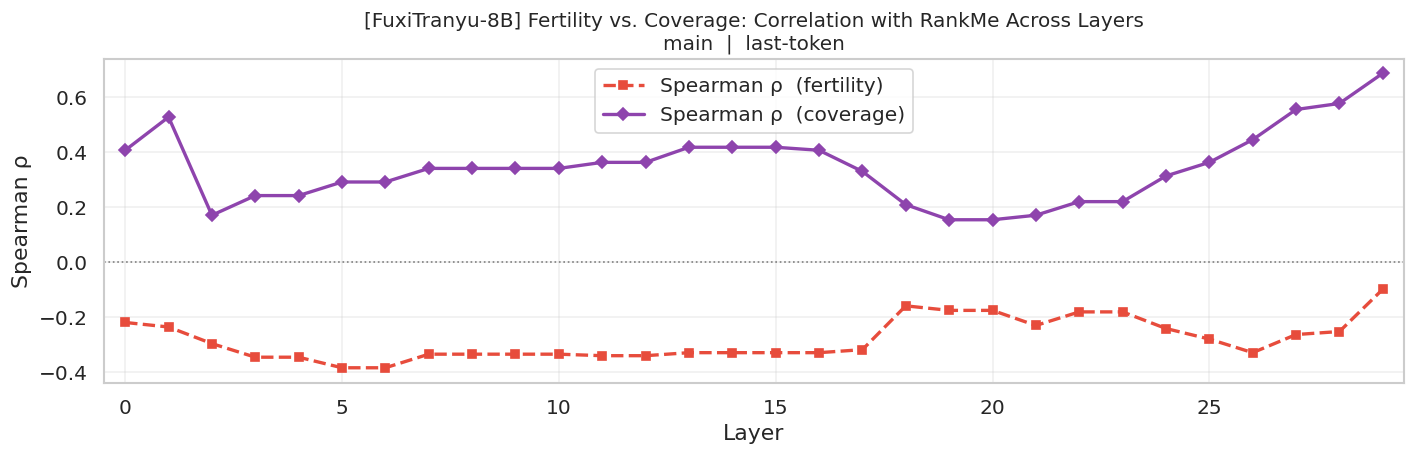

In [12]:
if not vocab_coverage_pct:
    print('No vocabulary coverage data — run the COMPUTE block with COMPUTE=True.')
else:
    common_cov_langs = [l for l in common_langs if l in vocab_coverage_pct]
    cov_prs, cov_rhos, cov_pvals = [], [], []
    for layer in layers:
        sub = df_final[df_final.layer == layer]
        xs_c, ys_r = [], []
        for lang in common_cov_langs:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs_c.append(vocab_coverage_pct[lang])
                ys_r.append(row.rankme.values[0])
        if len(xs_c) < 3:
            cov_prs.append(np.nan); cov_rhos.append(np.nan); cov_pvals.append(np.nan)
            continue
        r, p   = pearsonr(xs_c, ys_r)
        rho, _ = spearmanr(xs_c, ys_r)
        cov_prs.append(r); cov_rhos.append(rho); cov_pvals.append(p)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(layer_nums, rhos,     's--', color='#e74c3c', lw=2, ms=5,
            label='Spearman \u03c1  (fertility)')
    ax.plot(layer_nums, cov_rhos, 'D-',  color='#8e44ad', lw=2, ms=5,
            label='Spearman \u03c1  (coverage)')
    ax.axhline(0, color='gray', lw=1, ls=':')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Spearman \u03c1')
    ax.set_title(
        f'[{MODEL_LABEL}] Fertility vs. Coverage: Correlation with RankMe Across Layers\n'
        f'{FINAL_CKPT}  |  last-token',
        fontsize=12,
    )
    ax.legend()
    ax.set_xlim(-0.5, layer_nums[-1] + 0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{STATIC_DIR}/coverage_vs_fertility_corr_{MODEL_LABEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Training Dynamics by Fertility Tier

We split the languages into three equal-sized fertility tiers (low / medium / high) and track mean RankMe over training at the **middle layer** — the depth where the most active learning of linguistic structure typically occurs.

A widening gap between tiers during training would confirm H3: the model learns more effective representations for low-fertility languages more quickly.

Low  fertility: ['Japanese', 'Chinese', 'Vietnamese', 'Spanish']
Mid  fertility: ['English', 'French', 'Indonesian', 'Italian']
High fertility: ['Arabic', 'German', 'Turkish', 'Swahili', 'Hindi']


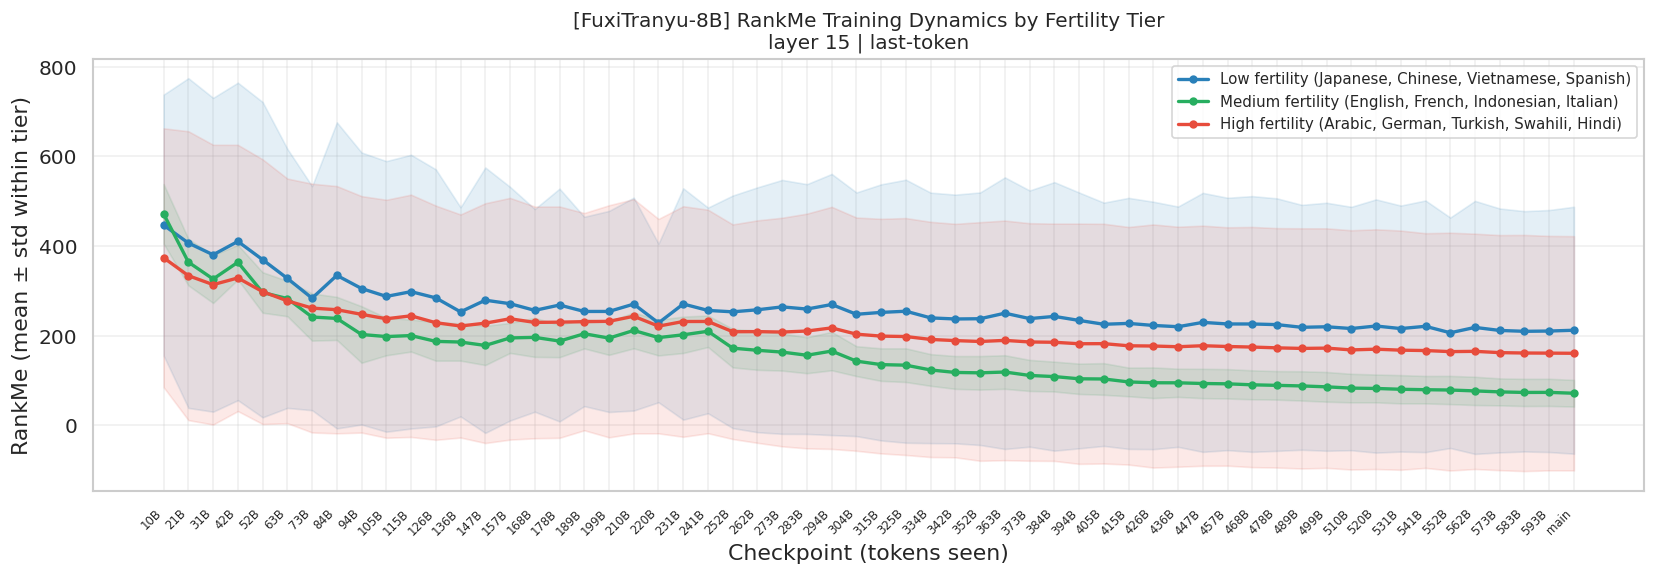

In [13]:
df_fert_sorted = (df_fert[df_fert.language.isin(common_langs)]
                  .sort_values("fertility").reset_index(drop=True))
k = max(1, len(df_fert_sorted) // 3)
low_tier  = df_fert_sorted.iloc[:k].language.tolist()
mid_tier  = df_fert_sorted.iloc[k:2*k].language.tolist()
high_tier = df_fert_sorted.iloc[2*k:].language.tolist()

print("Low  fertility:", low_tier)
print("Mid  fertility:", mid_tier)
print("High fertility:", high_tier)

TIERS = {
    "Low":    (low_tier,  "#2980b9"),
    "Medium": (mid_tier,  "#27ae60"),
    "High":   (high_tier, "#e74c3c"),
}
mid_layer = layers[len(layers) // 2]
df_mid = df_last[df_last.layer == mid_layer]

fig, ax = plt.subplots(figsize=(14, 5))
for tier, (langs, color) in TIERS.items():
    records = []
    for ci, ckpt in enumerate(checkpoints):
        sub = df_mid[(df_mid.checkpoint == ckpt) & (df_mid.dataset.isin(langs))]
        if not sub.empty:
            records.append({"idx": ci, "mean": sub.rankme.mean(), "std": sub.rankme.std()})
    if not records:
        continue
    tr = pd.DataFrame(records).sort_values("idx")
    xs = tr.idx.values
    ys = tr["mean"].values
    ax.plot(xs, ys, "o-", color=color, lw=2, ms=4,
            label=f"{tier} fertility ({', '.join(langs)})")
    ax.fill_between(xs, ys - tr["std"].values, ys + tr["std"].values, alpha=0.12, color=color)

ax.set_xticks(range(len(checkpoints)))
ax.set_xticklabels(ckpt_labels, rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Checkpoint (tokens seen)")
ax.set_ylabel("RankMe (mean \u00b1 std within tier)")
ax.set_title(
    f"[{MODEL_LABEL}] RankMe Training Dynamics by Fertility Tier\n"
    f"layer {layer_num(mid_layer)} | last-token",
    fontsize=12,
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/training_dynamics_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

### 4b. Spearman ρ Heatmap — All Checkpoints × All Layers

Each cell shows the Spearman rank correlation between fertility and RankMe across the languages for a given (checkpoint, layer) pair.

- **Blue**: higher fertility → higher RankMe (model compensates with richer representations)  
- **Red**: higher fertility → lower RankMe (fragmented tokens lead to more degenerate geometry)  
- **White**: no correlation

This view reveals *when* and *where* in the network the fertility signal emerges during training.

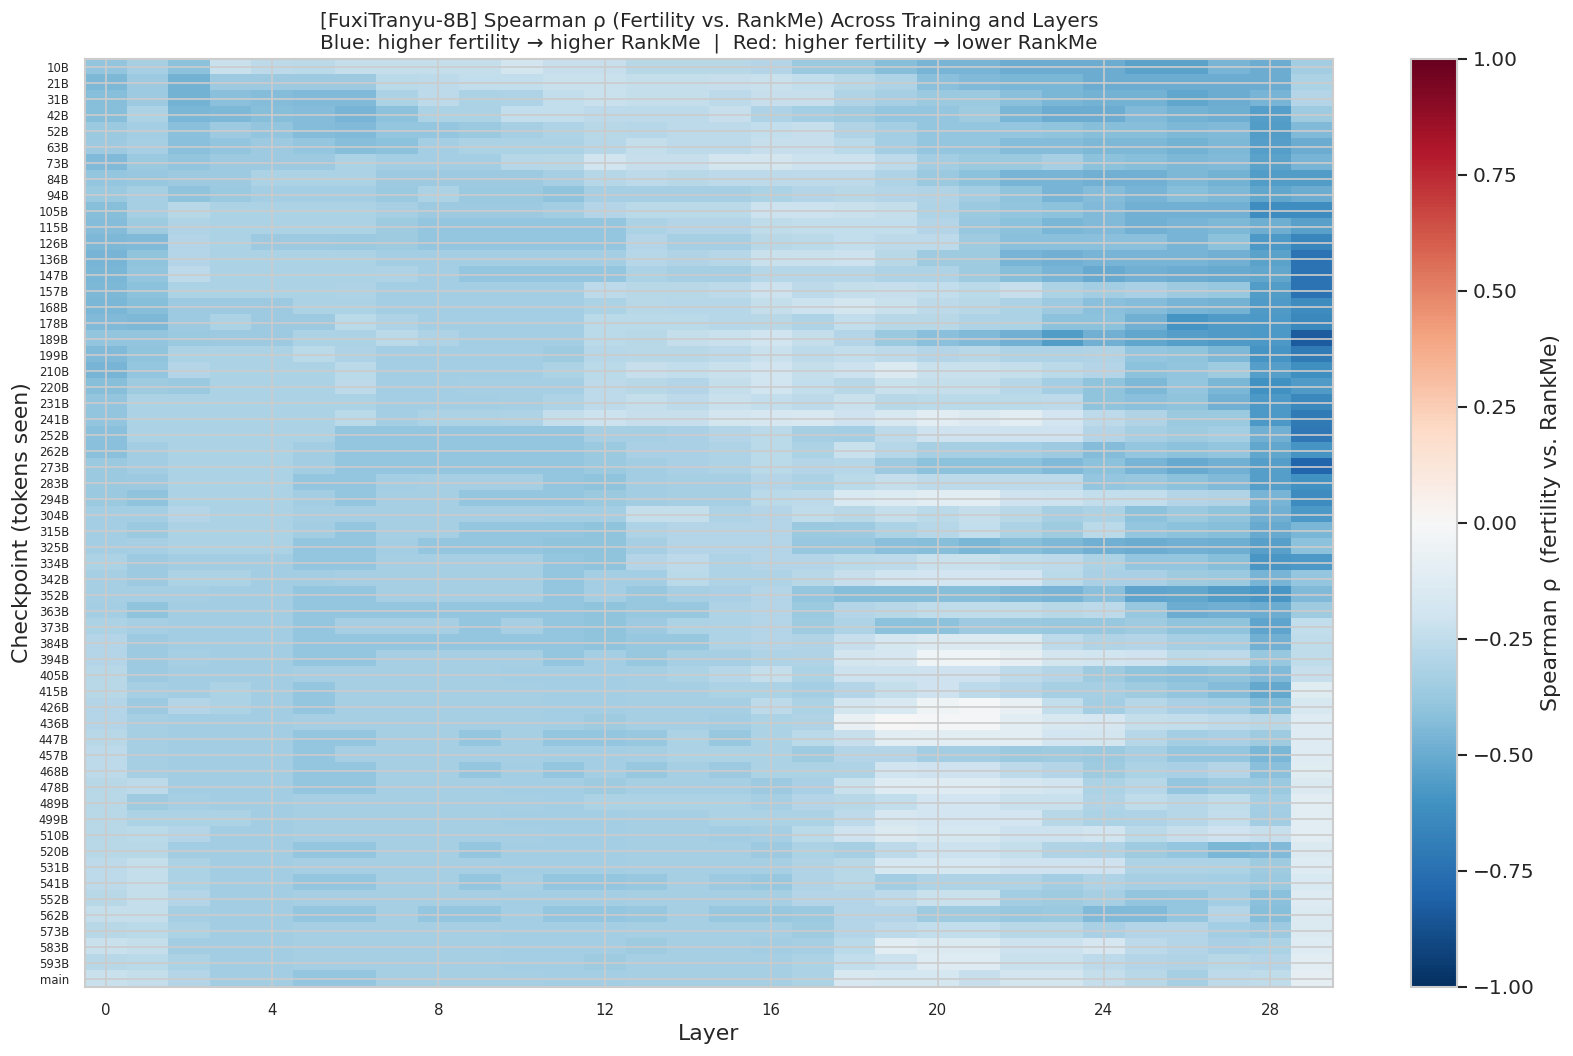

Mean Spearman ρ across all (checkpoint, layer) pairs: -0.334
  < 0: fertility tends to DECREASE RankMe


In [14]:
rho_mat = np.full((len(checkpoints), len(layers)), np.nan)
for ci, ckpt in enumerate(checkpoints):
    for li, layer in enumerate(layers):
        sub = df_last[(df_last.checkpoint == ckpt) & (df_last.layer == layer)]
        xs, ys = [], []
        for lang in common_langs:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs.append(fertility[lang])
                ys.append(row.rankme.values[0])
        if len(xs) >= 3:
            rho, _ = spearmanr(xs, ys)
            rho_mat[ci, li] = rho

xtick_pos  = list(range(0, len(layers), 4))
xtick_labs = [layer_nums[i] for i in xtick_pos]

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(rho_mat, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=ax, label="Spearman \u03c1  (fertility vs. RankMe)")
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labs, fontsize=9)
ax.set_yticks(range(len(checkpoints)))
ax.set_yticklabels(ckpt_labels, fontsize=7)
ax.set_xlabel("Layer")
ax.set_ylabel("Checkpoint (tokens seen)")
ax.set_title(
    f"[{MODEL_LABEL}] Spearman \u03c1 (Fertility vs. RankMe) Across Training and Layers\n"
    "Blue: higher fertility \u2192 higher RankMe  |  Red: higher fertility \u2192 lower RankMe",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/spearman_heatmap_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

mean_rho = np.nanmean(rho_mat)
print(f"Mean Spearman \u03c1 across all (checkpoint, layer) pairs: {mean_rho:.3f}")
print("  > 0: fertility tends to INCREASE RankMe" if mean_rho > 0
      else "  < 0: fertility tends to DECREASE RankMe")

## 5. Conclusions

